In [47]:
import pandas as pd
import seaborn as sns
import matplotlib
from datetime import datetime
import requests
import json
import numpy as np
import ast
import re
from collections import Counter
import datetime
import os
import openai
import logging
import traceback
import time

In [48]:
openai.api_key = 'INSERT KEY HERE'

In [49]:
logger = logging.getLogger(__name__)  
logger.setLevel(logging.INFO)

file_handler = logging.FileHandler('openAI_'+datetime.datetime.today().strftime('%Y-%m-%d')+'.log')
formatter = logging.Formatter('%(asctime)s:%(levelname)s:%(message)s')
file_handler.setFormatter(formatter)

logger.addHandler(file_handler)

logger.info('Hello World')

# Read In Wikipedia Data

In [50]:
wikipedia_movies = pd.read_csv(
    "Scraped movie data with preprocesing.csv", low_memory=False
)

In [51]:
wikipedia_movies.shape

(12549, 48)

In [52]:
wikipedia_movies.iloc[8].new_plot

"Eddie Ryan , a tough, no-nonsense, abrasive and racist Irish NYPD cop, has to turn in his badge after scuffling with a Puerto Rican suspect who then falls to his death from a rooftop, but that doesn't stop him from heading out on a one-man crusade to find out who killed his partner of three years, Gigi Caputo (Louis Cosentino), all the while neglecting his new live-in girlfriend, Maureen .  Ryan's search leads him to Puerto Rican drug kingpin Sweet Willie , and a shipment of guns for Puerto Rican independentistas."

#### Convert Columns of interest to strings for prompts

In [53]:
wikipedia_movies_dtypes = wikipedia_movies.dtypes
print("genres datatype: " + str(wikipedia_movies_dtypes.genres))
print("new_plot datatype: " + str(wikipedia_movies_dtypes.new_plot))

genres datatype: object
new_plot datatype: object


In [54]:
wikipedia_movies['genres'] = wikipedia_movies['genres'].astype("string")

In [55]:
wikipedia_movies['new_plot'] = wikipedia_movies['new_plot'].astype("string")

In [56]:
wikipedia_movies.iloc[8].new_plot

"Eddie Ryan , a tough, no-nonsense, abrasive and racist Irish NYPD cop, has to turn in his badge after scuffling with a Puerto Rican suspect who then falls to his death from a rooftop, but that doesn't stop him from heading out on a one-man crusade to find out who killed his partner of three years, Gigi Caputo (Louis Cosentino), all the while neglecting his new live-in girlfriend, Maureen .  Ryan's search leads him to Puerto Rican drug kingpin Sweet Willie , and a shipment of guns for Puerto Rican independentistas."

### Remove any duplicate plots and Analyze - Before running OpenAI requests

In [57]:
wikipedia_movies_dedup = wikipedia_movies.drop_duplicates(subset=['new_plot'], keep=False)

#### Looks like we removed 12549 - 11952 = 597 duplicate new_plots

In [58]:
wikipedia_movies_dedup.shape

(11952, 48)

In [59]:
wikipedia_movies_dedup.isna().sum()

year                                   0
href                                   0
title                                  0
plot                                1359
premise                            11736
synopsis                           11613
directed_by                          136
screenplay_by                       7798
based_on                            7853
starring                             318
box_office                          3176
written_by                          4491
budget                              4321
omdb_response                          0
omdb_title                          1213
genres                                 0
omdb_plot                           1337
release_date                        1345
omdb_director                        127
omdb_writer                          306
omdb_actors                           52
imdb_score                          1440
imdb_votes                          1406
rotten_tomatoes_score               3751
metacritic_score

In [60]:
count = wikipedia_movies_dedup['new_plot'].str.split().str.len()
count.index = count.index.astype(str) + ' words:'
count.sort_index(inplace=True)

#### Average Word count length

In [61]:
count.mean()

481.92796184738955

#### Max word count length

In [62]:
count.max()

2314

In [63]:
count = wikipedia_movies_dedup['new_plot'].str.len()
count.index = count.index.astype(str) + ' words:'
count.sort_index(inplace=True)

#### Average Character count length

In [64]:
count.mean()

2820.6610609103077

#### Max Character length

In [65]:
count.max()

13052

In [66]:
wikipedia_movies_dedup['new_plot_word_cnt'] = wikipedia_movies_dedup['new_plot'].str.split().str.len()

C:\Users\neil_\AppData\Local\Temp\ipykernel_10892\2807794058.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wikipedia_movies_dedup['new_plot_word_cnt'] = wikipedia_movies_dedup['new_plot'].str.split().str.len()


#### How many movies have new_plot word count 10?

In [67]:
wikipedia_movies_dedup[wikipedia_movies_dedup['new_plot_word_cnt'] < 10].shape[0]

8

#### Under 15?

In [68]:
wikipedia_movies_dedup[wikipedia_movies_dedup['new_plot_word_cnt'] < 15].shape[0]

46

####  Under 30?

In [69]:
wikipedia_movies_dedup[wikipedia_movies_dedup['new_plot_word_cnt'] < 30].shape[0]

272

##### Under 50?

In [70]:
wikipedia_movies_dedup[wikipedia_movies_dedup['new_plot_word_cnt'] < 50].shape[0]

694

#### Under 100?

In [71]:
wikipedia_movies_dedup[wikipedia_movies_dedup['new_plot_word_cnt'] < 100].shape[0]

1719

In [72]:
wikipedia_movies_dedup = wikipedia_movies_dedup[wikipedia_movies_dedup['new_plot_word_cnt'] >= 10]

#### We are setting cut off at 10 words for the new_plot feature

In [73]:
wikipedia_movies_dedup.shape

(11944, 49)

#### Lets make a histogram of plot count

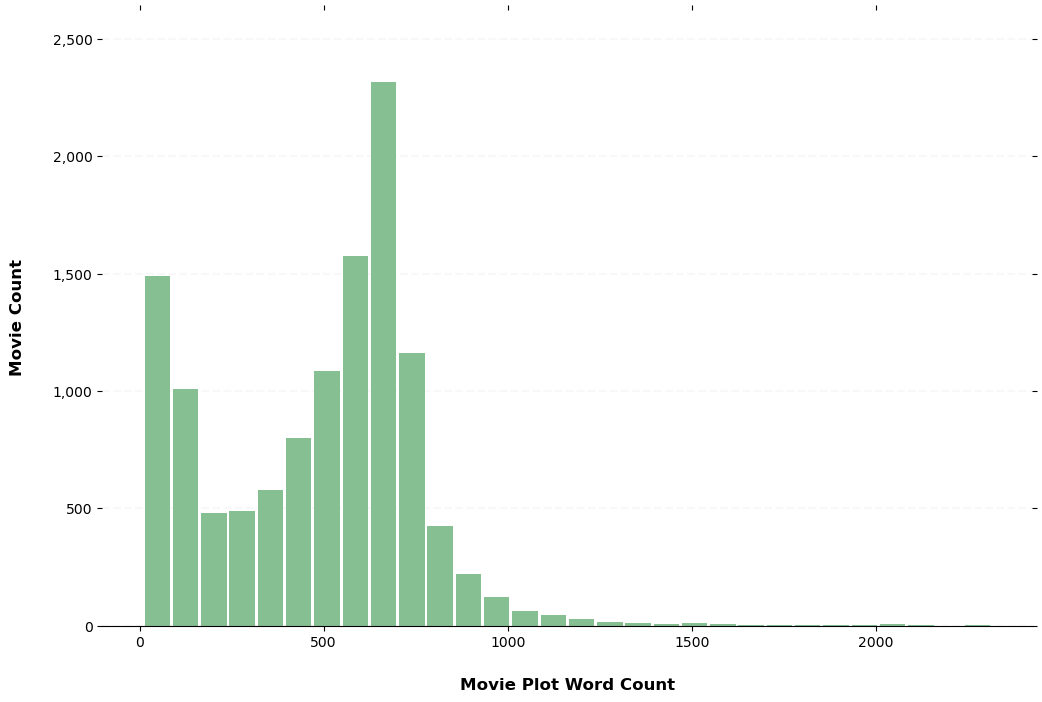

In [74]:
ax = wikipedia_movies_dedup.hist(column='new_plot_word_cnt', bins=30, grid=False, figsize=(12,8), color='#86bf91', zorder=2, rwidth=0.9)
ax = ax[0]
for x in ax:

    # Despine
    x.spines['right'].set_visible(False)
    x.spines['top'].set_visible(False)
    x.spines['left'].set_visible(False)

    # Switch off ticks
    x.tick_params(axis="both", which="both", bottom="off", top="off", labelbottom="on", left="off", right="off", labelleft="on")

    # Draw horizontal axis lines
    vals = x.get_yticks()
    for tick in vals:
        x.axhline(y=tick, linestyle='dashed', alpha=0.4, color='#eeeeee', zorder=1)

    # Remove title
    x.set_title("")

    # Set x-axis label
    x.set_xlabel("Movie Plot Word Count", labelpad=20, weight='bold', size=12)

    # Set y-axis label
    x.set_ylabel("Movie Count", labelpad=20, weight='bold', size=12)

    # Format y-axis label
    x.yaxis.set_major_formatter(matplotlib.ticker.StrMethodFormatter('{x:,g}'))

In [75]:
del wikipedia_movies_dedup['new_plot_word_cnt']

#### Lets also take a look at the number of NA values for features genre and new_plot

In [76]:
na_values_wiki_data = wikipedia_movies_dedup.isna().sum()

In [77]:
na_values_wiki_data['new_plot']

0

In [78]:
na_values_wiki_data['genres']

0

#### Lets take a look at how many empty lists in the feature genres

In [79]:
print(" Number of rows with []: " + str(len(wikipedia_movies_dedup[wikipedia_movies_dedup["genres"] == "['']"])))

 Number of rows with []: 1213


#### It looks like there are around 1,213 rows with empty genres

### Lets form the prompt using the features genre and new_plot

In [80]:
wikipedia_movies_dedup['new_plot'][10]

'Henry Wiggen is a star pitcher for the New York Mammoths, a fictional Major League Baseball team. He is a valuable player to his manager Dutch but is in a dispute with the team\'s ownership, holding out for a new contract and more money. Henry has a sideline as an insurance salesman working for the Arcturus Corporation, with ballplayers as his clients. Henry\'s friend Bruce Pearson, the team\'s catcher, is a player of limited skill and intellect. Teammates call Henry by the nickname "Author" because the brainy pitcher once wrote a book, although Bruce misunderstands and, with his thick Southern drawl, often calls him "Arthur" instead.\nHenry and Bruce leave the Mayo Clinic in Minnesota, where Bruce has been told he is terminally ill with Hodgkin\'s disease. They drive to Bruce\'s hometown in Georgia, because Bruce always wanted his only friend to see it. On their first night there, Bruce burns his old baseball memorabilia to acknowledge the inevitable end of his life.\nThe team knows 

In [81]:
wikipedia_movies_dedup['genres'][323]

"['Drama', ' Romance', ' Thriller']"

In [82]:
' and'.join(ast.literal_eval(wikipedia_movies_dedup['genres'][323]))

'Drama and Romance and Thriller'

In [83]:
prompt = 'Based on this movie with genres "'+ ' and'.join(ast.literal_eval(wikipedia_movies_dedup['genres'][10])) +'" and a plot "' + wikipedia_movies_dedup['new_plot'][10] + \
         '" rank each mood happy, sad, energetic, calm on a scale from 0 to 1.'

In [84]:
prompt

'Based on this movie with genres "Drama and Sport" and a plot "Henry Wiggen is a star pitcher for the New York Mammoths, a fictional Major League Baseball team. He is a valuable player to his manager Dutch but is in a dispute with the team\'s ownership, holding out for a new contract and more money. Henry has a sideline as an insurance salesman working for the Arcturus Corporation, with ballplayers as his clients. Henry\'s friend Bruce Pearson, the team\'s catcher, is a player of limited skill and intellect. Teammates call Henry by the nickname "Author" because the brainy pitcher once wrote a book, although Bruce misunderstands and, with his thick Southern drawl, often calls him "Arthur" instead.\nHenry and Bruce leave the Mayo Clinic in Minnesota, where Bruce has been told he is terminally ill with Hodgkin\'s disease. They drive to Bruce\'s hometown in Georgia, because Bruce always wanted his only friend to see it. On their first night there, Bruce burns his old baseball memorabilia t

## Lets try running an example openAI request  (uncomment to test)

In [85]:
#completion = openai.ChatCompletion.create(
#  model="gpt-3.5-turbo",
#  messages=[
#    {"role": "user", "content": prompt}
#  ]
#)
#
#print(completion.choices[0].message)

In [86]:
#content = completion.choices[0].message.content

In [87]:
#print(content)

In [88]:
#happy = re.search('Happy: \d.\d', content).group()
#sad = re.search("Sad: \d.\d", content).group()
#energetic = re.search("Energetic: \d.\d", content).group()
#calm = re.search("Calm: \d.\d", content).group()

In [89]:
#happy = re.search('\d.\d', content).group()
#sad = re.search('\d.\d', sad).group()
#energetic = re.search('\d.\d', energetic).group()
#calm = re.search('\d.\d', calm).group()

In [90]:
#happy = float(happy)
#sad = float(sad)
#energetic = float(energetic)
#calm = float(calm)

In [91]:
#print(happy)
#print(sad)
#print(energetic)
#print(calm)

### Now that we know enough about features new_plot and genres, let's write a function that will work for all scenarios 
##### (i.e. if genres doesn't exist, then don't use it in the prompt)

In [92]:

from tenacity import (
    retry,
    stop_after_attempt,
    wait_random_exponential,
    retry_if_exception_type
)  # for exponential backoff

@retry(
    retry=retry_if_exception_type((openai.error.APIError, openai.error.APIConnectionError, openai.error.RateLimitError, openai.error.ServiceUnavailableError, openai.error.Timeout)), 
    wait=wait_random_exponential(multiplier=1, max=60), 
    stop=stop_after_attempt(10)
)
def chat_completion_with_backoff(**kwargs):
    return openai.ChatCompletion.create(**kwargs)


In [93]:
def openAPI_call(prompt, row):
    happy_error     = False
    sad_error       = False
    energetic_error = False
    calm_error      = False
    '''
    completion = openai.ChatCompletion.create(
                  model="gpt-3.5-turbo",
                  messages=[
                    {"role": "user", "content": prompt}
                  ],
                  temperature=0.5,
                  request_timeout=45,
                )
    '''
    completion = chat_completion_with_backoff(
                    model="gpt-3.5-turbo",
                    messages=[
                        {"role": "user", "content": prompt}
                    ],
                    temperature=0.5
                 )

    content = completion.choices[0].message.content
    content = content.lower()

    try:
        happy = re.search('happy: \d.\d', content).group()
        happy = re.search('\d.\d', happy).group()
        happy = float(happy)
    except AttributeError:
        happy = 0.0
        happy_error = True
    
    try:
        sad = re.search("sad: \d.\d", content).group()
        sad = re.search('\d.\d', sad).group()
        sad = float(sad)
    except AttributeError:
        sad = 0.0
        sad_error = True
        
    try:
        energetic = re.search("energetic: \d.\d", content).group()
        energetic = re.search('\d.\d', energetic).group()
        energetic = float(energetic)
    except AttributeError:
        energetic = 0.0
        energetic_error = True
        
    try:
        calm = re.search("calm: \d.\d", content).group()
        calm = re.search('\d.\d', calm).group()
        calm = float(calm)
    except AttributeError:
        calm = 0.0
        calm_error = True
    
    if happy_error or sad_error or energetic_error or calm_error:
        logger.error("--------------------")
    if happy_error:
        logger.info("No Happy Score Found")
    if sad_error:
        logger.info("No Sad Score Found")
    if energetic_error:
        logger.info("No Energetic Score Found")
    if calm_error:
        logger.info("No Calm Score Found")
    
    if happy_error or sad_error or energetic_error or calm_error:
        logger.info("prompt: " + prompt)
        logger.info("GPT response: " + content)
        logger.info("\n")
        logger.info("movie title: "+ row.title)
        logger.info("new_plot: "+ row.new_plot)
        logger.info("genres: "+ row.genres)
        
        logger.error("--------------------")
    error_occured = True if happy_error or sad_error or energetic_error or calm_error else False
    return happy, sad, energetic, calm, {'error' : error_occured, 'happy' : happy_error, 'sad' : \
                                         sad_error, 'energetic' : energetic_error, 'calm' : calm_error \
                                        }

In [94]:
def generate_prompt(row):
    if row.genres and row.new_plot:
        prompt = 'Based on a movie with genres "'+' and'.join(ast.literal_eval(row.genres)) + \
                 '" and an overall plot "' + row.new_plot + \
                 '" rank each mood happy, sad, energetic, calm on a scale from 0.00 to 1.00 like' \
                 ' this Happy: x.xx Sad: x.xx Energetic: x.xx Calm: x.xx'
        # Make API Call
        happy,sad,energetic,calm,err_d = openAPI_call(prompt, row)
    elif row.new_plot:
        #prompt = 'Based on this movie with a plot "' + row['new_plot']+\
        #'" rank each mood happy, sad, energetic, calm on a scale from 0.00 to 1.00.'
        prompt = 'Based on a movie with an overall plot "' + row['new_plot'] + \
                 '" rank each mood happy, sad, energetic, calm on a scale from 0.00 to 1.00 like' \
                 'this Happy: x.xx Sad: x.xx Energetic: x.xx Calm: x.xx'
        # Make API Call\
        happy,sad,energetic,calm,err_d = openAPI_call(prompt, row)
    else:
        logger.error("--------------------")
        logger.info("Insufficient data: ")
        logger.info("movie title: "+ row.title)
        logger.info("new_plot: "+ row.new_plot)
        logger.info("genres: "+ row.genres)
        logger.error("--------------------")
        return (0.0,0.0,0.0,0.0,{'error' : True, 'happy' : None, 'sad' : \
                                 None, 'energetic' : None, 'calm' : None \
                                }
               )

    return (happy,sad,energetic,calm,err_d)

In [95]:
#wikipedia_movies_dedup_random_5000 = wikipedia_movies_dedup.sample(n=5)

In [96]:
#wikipedia_movies_dedup_random_100["happy"] = 0.0
#wikipedia_movies_dedup_random_100["sad"] = 0.0
#wikipedia_movies_dedup_random_100["energetic"] = 0.0
#wikipedia_movies_dedup_random_100["calm"] = 0.0
#wikipedia_movies_dedup_random_100["error_labeling"] = ""

In [97]:
#wikipedia_movies_dedup_random_100.shape

In [98]:
#%%time
#counter = 0
#for row in wikipedia_movies_dedup_random_100.itertuples():
#    happy,sad,energetic,calm,err_d = generate_prompt(row)
#    wikipedia_movies_dedup_random_100.at[row.Index, 'happy'] = happy
#    wikipedia_movies_dedup_random_100.at[row.Index, 'sad'] = sad
#    wikipedia_movies_dedup_random_100.at[row.Index, 'energetic'] = energetic
#    wikipedia_movies_dedup_random_100.at[row.Index, 'calm'] = calm
#    if err_d['error']:
#        error_string = ''
#        if err_d['happy']:
#            error_string += "No Happy Score Found "
#        if err_d['sad']:
#            error_string += "No Sad Score Found "
#        if err_d['energetic']:
#            error_string += "No Energetic Score Found "
#        if err_d['calm']:
#            error_string += "No Calm Score Found "
#        wikipedia_movies_dedup_random_100.at[row.Index, 'error_labeling'] = error_string
#    counter += 1
#    logger.info("completed " + str(counter) + " rows")

In [99]:
wikipedia_movies_dedup["happy"] = 0.0
wikipedia_movies_dedup["sad"] = 0.0
wikipedia_movies_dedup["energetic"] = 0.0
wikipedia_movies_dedup["calm"] = 0.0
wikipedia_movies_dedup["error_labeling"] = ""

In [100]:
wiki_movies_first_3000 = wikipedia_movies_dedup.iloc[:3000]

In [101]:
labels_saved = None
if os.path.exists('wiki_movies_mood_label_by_gpt-3.5-turbo.csv'):
    labels_saved = pd.read_csv("wiki_movies_mood_label_by_gpt-3.5-turbo.csv", low_memory=False)

In [102]:
wiki_movies_first_3000.shape

(3000, 53)

In [103]:
#wikipedia_movies_dedup = wikipedia_movies_dedup.sample(n=5)

In [104]:
%%time
counter = 0
temp_df = pd.DataFrame()
for row in wiki_movies_first_3000.itertuples():
    try:
        happy,sad,energetic,calm,err_d = generate_prompt(row)
    except Exception as e:
        logger.info("--------------------")
        logger.info("ROW FAILED: ")
        logger.info("movie title: "+ row.title)
        logger.info("new_plot: "+ row.new_plot)
        logger.info("genres: "+ row.genres)
        logger.info("--------------------")
        logger.error(traceback.format_exc())
        continue
    wiki_movies_first_3000.at[row.Index, 'happy'] = happy
    wiki_movies_first_3000.at[row.Index, 'sad'] = sad
    wiki_movies_first_3000.at[row.Index, 'energetic'] = energetic
    wiki_movies_first_3000.at[row.Index, 'calm'] = calm
    if err_d['error']:
        error_string = ''
        if err_d['happy']:
            error_string += "No Happy Score Found "
        if err_d['sad']:
            error_string += "No Sad Score Found "
        if err_d['energetic']:
            error_string += "No Energetic Score Found "
        if err_d['calm']:
            error_string += "No Calm Score Found "
        wiki_movies_first_3000.at[row.Index, 'error_labeling'] = error_string
    counter += 1
    logger.info("completed " + str(counter) + " rows")
    #temp_df._append(row, ignore_index = True)
    #wiki_movies_first_3000.to_csv('movies_saved.csv', index=False, mode='a+', header=False)


CPU times: total: 34.2 s
Wall time: 13h 47min 20s


In [105]:
wiki_movies_first_3000.to_csv('wiki_movies_mood_label_by_gpt-3.5-turbo'+ \
                                         datetime.datetime.today().strftime('%Y-%m-%d')+'.csv')

In [107]:
wiki_movies_3000_to_6000= wikipedia_movies_dedup.iloc[3001:6000]

In [108]:
wiki_movies_3000_to_6000.shape

(2999, 53)

In [109]:
%%time
counter = 0
temp_df = pd.DataFrame()
for row in wiki_movies_3000_to_6000.itertuples():
    try:
        happy,sad,energetic,calm,err_d = generate_prompt(row)
    except Exception as e:
        logger.info("--------------------")
        logger.info("ROW FAILED: ")
        logger.info("movie title: "+ row.title)
        logger.info("new_plot: "+ row.new_plot)
        logger.info("genres: "+ row.genres)
        logger.info("--------------------")
        logger.error(traceback.format_exc())
        continue
    wiki_movies_3000_to_6000.at[row.Index, 'happy'] = happy
    wiki_movies_3000_to_6000.at[row.Index, 'sad'] = sad
    wiki_movies_3000_to_6000.at[row.Index, 'energetic'] = energetic
    wiki_movies_3000_to_6000.at[row.Index, 'calm'] = calm
    if err_d['error']:
        error_string = ''
        if err_d['happy']:
            error_string += "No Happy Score Found "
        if err_d['sad']:
            error_string += "No Sad Score Found "
        if err_d['energetic']:
            error_string += "No Energetic Score Found "
        if err_d['calm']:
            error_string += "No Calm Score Found "
        wiki_movies_3000_to_6000.at[row.Index, 'error_labeling'] = error_string
    counter += 1
    logger.info("completed " + str(counter) + " rows")
    #temp_df._append(row, ignore_index = True)
    #wiki_movies_first_3000.to_csv('movies_saved.csv', index=False, mode='a+', header=False)

CPU times: total: 26.4 s
Wall time: 9h 8min 35s


In [111]:
wiki_movies_3000_to_6000.to_csv('wiki_movies_mood_label_by_gpt-3.5-turbo'+ \
                                         datetime.datetime.today().strftime('%Y-%m-%d')+'.csv')

In [112]:
wiki_movies_6000_to_9000 = wikipedia_movies_dedup.iloc[6001:9001]

In [113]:
%%time
counter = 0
temp_df = pd.DataFrame()
for row in wiki_movies_6000_to_9000.itertuples():
    try:
        happy,sad,energetic,calm,err_d = generate_prompt(row)
    except Exception as e:
        logger.info("--------------------")
        logger.info("ROW FAILED: ")
        logger.info("movie title: "+ row.title)
        logger.info("new_plot: "+ row.new_plot)
        logger.info("genres: "+ row.genres)
        logger.info("--------------------")
        logger.error(traceback.format_exc())
        continue
    wiki_movies_6000_to_9000.at[row.Index, 'happy'] = happy
    wiki_movies_6000_to_9000.at[row.Index, 'sad'] = sad
    wiki_movies_6000_to_9000.at[row.Index, 'energetic'] = energetic
    wiki_movies_6000_to_9000.at[row.Index, 'calm'] = calm
    if err_d['error']:
        error_string = ''
        if err_d['happy']:
            error_string += "No Happy Score Found "
        if err_d['sad']:
            error_string += "No Sad Score Found "
        if err_d['energetic']:
            error_string += "No Energetic Score Found "
        if err_d['calm']:
            error_string += "No Calm Score Found "
        wiki_movies_6000_to_9000.at[row.Index, 'error_labeling'] = error_string
    counter += 1
    logger.info("completed " + str(counter) + " rows")
    #temp_df._append(row, ignore_index = True)
    #wiki_movies_first_3000.to_csv('movies_saved.csv', index=False, mode='a+', header=False)

CPU times: total: 34.6 s
Wall time: 13h 40min 9s


In [114]:
wiki_movies_6000_to_9000.to_csv('wiki_movies_mood_label_by_gpt-3.5-turbo'+ \
                                         datetime.datetime.today().strftime('%Y-%m-%d')+'_6000_to_9000.csv')

In [115]:
wiki_movies_9000_to_12000 = wikipedia_movies_dedup.iloc[9001:]

In [116]:
%%time
counter = 0
temp_df = pd.DataFrame()
for row in wiki_movies_9000_to_12000.itertuples():
    try:
        happy,sad,energetic,calm,err_d = generate_prompt(row)
    except Exception as e:
        logger.info("--------------------")
        logger.info("ROW FAILED: ")
        logger.info("movie title: "+ row.title)
        logger.info("new_plot: "+ row.new_plot)
        logger.info("genres: "+ row.genres)
        logger.info("--------------------")
        logger.error(traceback.format_exc())
        continue
    wiki_movies_9000_to_12000.at[row.Index, 'happy'] = happy
    wiki_movies_9000_to_12000.at[row.Index, 'sad'] = sad
    wiki_movies_9000_to_12000.at[row.Index, 'energetic'] = energetic
    wiki_movies_9000_to_12000.at[row.Index, 'calm'] = calm
    if err_d['error']:
        error_string = ''
        if err_d['happy']:
            error_string += "No Happy Score Found "
        if err_d['sad']:
            error_string += "No Sad Score Found "
        if err_d['energetic']:
            error_string += "No Energetic Score Found "
        if err_d['calm']:
            error_string += "No Calm Score Found "
        wiki_movies_9000_to_12000.at[row.Index, 'error_labeling'] = error_string
    counter += 1
    logger.info("completed " + str(counter) + " rows")
    #temp_df._append(row, ignore_index = True)
    #wiki_movies_first_3000.to_csv('movies_saved.csv', index=False, mode='a+', header=False)

CPU times: total: 29.6 s
Wall time: 13h 29min 58s


In [117]:
wiki_movies_9000_to_12000.to_csv('wiki_movies_mood_label_by_gpt-3.5-turbo'+ \
                                         datetime.datetime.today().strftime('%Y-%m-%d')+'_9000_to_12000.csv')